這個程式碼參考了  
"C:\MasterDegResearch_ML_0626New\2025Autumn_ML-project-DiffusionModel_02\000_WellTrainedFiles\20260518-0603-0616_code\1D-OU_LDSM-LESM-LISM_IDSM.ipynb"  
這個檔案。
## 目標
確認我要做的事情可以對1D的OU 數據跑

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================================
# OU Dataset
# x0 ~ N(10, 2)
# dX_t = - beta X_t dt + sigma dW_t
# ============================================================

mu0 = 10.0
var0 = 2.0
std0 = np.sqrt(var0)

beta = 1.0
sigma = np.sqrt(beta * 2.0)
t = 5.0

N = 10000

# x0 ~ N(mu0, var0)
x0_np = np.random.normal(
    mu0,
    std0,
    N
).astype(np.float32)

# OU conditional mean and variance
a_t = np.exp(-beta * t)

cond_var_t = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
cond_std_t = np.sqrt(cond_var_t)

# xt | x0
eps_np = np.random.randn(N).astype(np.float32)

xt_np = (
    a_t * x0_np
    + cond_std_t * eps_np
).astype(np.float32)

# OU marginal mean and variance
mu_t = a_t * mu0

var_t = (
    (a_t**2) * var0
    + cond_var_t
)

# exact marginal score ∇ log p_t(x)
score_t_np = (
    -(xt_np - mu_t)
    / var_t
).astype(np.float32)

# conditional score ∇ log p(xt | x0)
cond_score_np = (
    -(xt_np - a_t * x0_np)
    / cond_var_t
).astype(np.float32)

# torch tensors
x0_train = torch.tensor(x0_np).view(-1, 1)
xt_train = torch.tensor(xt_np).view(-1, 1)
score_t_train = torch.tensor(score_t_np).view(-1, 1)
cond_score_train = torch.tensor(cond_score_np).view(-1, 1)

print("mu_t =", mu_t)
print("var_t =", var_t)
print("conditional variance =", cond_var_t)
print("xt empirical mean =", xt_np.mean())
print("xt empirical var =", xt_np.var())

mu_t = 0.06737946999085467
var_t = 1.0000453999297627
conditional variance = 0.9999546000702377
xt empirical mean = 0.07774304
xt empirical var = 0.9927572


In [2]:
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [3]:
# ============================================================
# Time-dependent OU training
# with ESM / ISM / DSM / I_DSM
# ============================================================

T = 5.0

epochs = 5000
batch_size = 2048

L_ESM_history = []
L_ISM_history = []
L_DSM_history = []
I_DSM_history = []

for epoch in range(epochs):

    # ========================================================
    # sample x0
    # ========================================================

    x0 = (
        torch.randn(batch_size, 1)
        * np.sqrt(var0)
        + mu0
    )

    # ========================================================
    # sample t ~ Uniform(0,T)
    # ========================================================

    eps_t = 0.05

    t_batch = (
        eps_t
        + (T - eps_t) * torch.rand(batch_size, 1)
    )

    # ========================================================
    # OU coefficients
    # ========================================================

    a_t = torch.exp(-beta * t_batch)

    cond_var_t = (
        sigma**2 / (2 * beta)
        * (1 - torch.exp(-2 * beta * t_batch))
    )

    cond_std_t = torch.sqrt(cond_var_t)

    # ========================================================
    # generate xt
    # ========================================================

    eps = torch.randn_like(x0)

    xt = (
        a_t * x0
        + cond_std_t * eps
    )

    xt.requires_grad_(True)

    # ========================================================
    # marginal distribution p_t(x)
    # ========================================================

    mu_t = a_t * mu0

    var_t = (
        (a_t**2) * var0
        + cond_var_t
    )

    # ========================================================
    # exact marginal score
    # ∇ log p_t(x_t)
    # ========================================================

    score_t = (
        -(xt - mu_t)
        / var_t
    )

    # ========================================================
    # conditional score
    # ∇ log p(x_t | x0)
    # ========================================================

    cond_score = (
        -(xt - a_t * x0)
        / cond_var_t
    )

    # ========================================================
    # network prediction
    # ========================================================

    pred_score = model(xt, t_batch)

    # ========================================================
    # 1. L_ESM
    # ========================================================

    L_ESM = (
        (pred_score - score_t)**2
    ).mean()

    # ========================================================
    # 2. L_ISM
    # ========================================================

    div_score = torch.autograd.grad(
        outputs=pred_score.sum(),
        inputs=xt,
        create_graph=True
    )[0]

    L_ISM = (
        pred_score**2
        + 2 * div_score
    ).mean()

    # ========================================================
    # 3. L_DSM
    # ========================================================

    term1 = (score_t**2).mean()

    term2 = (cond_score**2).mean()

    L_DSM = (
        L_ESM
        - term1
        + term2
    )

    # ========================================================
    # 4. Indicator I_DSM
    # ========================================================

    I_DSM = (
        pred_score**2
        - pred_score * cond_score
    ).mean()

    # ========================================================
    # train
    # ========================================================

    loss = L_ESM

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ========================================================
    # record
    # ========================================================

    L_ESM_history.append(L_ESM.item())
    L_ISM_history.append(L_ISM.item())
    L_DSM_history.append(L_DSM.item())
    I_DSM_history.append(I_DSM.item())

    # ========================================================
    # print
    # ========================================================

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"L_ESM = {L_ESM.item():.8f} | "
            f"L_ISM = {L_ISM.item():.8f} | "
            f"L_DSM = {L_DSM.item():.8f} | "
            f"I_DSM = {I_DSM.item():.8f}"
        )

Epoch    0 | L_ESM = 1.09329855 | L_ISM = 0.21259029 | L_DSM = 1.44820714 | I_DSM = 0.14234969
Epoch  500 | L_ESM = 0.00065663 | L_ISM = -0.93982601 | L_DSM = 0.26679373 | I_DSM = -0.00105718
Epoch 1000 | L_ESM = 0.00051188 | L_ISM = -0.89435416 | L_DSM = 0.29830950 | I_DSM = 0.00711839
Epoch 1500 | L_ESM = 0.00027029 | L_ISM = -0.93612075 | L_DSM = 0.33055240 | I_DSM = -0.00501361
Epoch 2000 | L_ESM = 0.00017633 | L_ISM = -0.94159359 | L_DSM = 0.32630122 | I_DSM = -0.00441320
Epoch 2500 | L_ESM = 0.00079747 | L_ISM = -0.94293624 | L_DSM = 0.31387508 | I_DSM = -0.00009597
Epoch 3000 | L_ESM = 0.00012592 | L_ISM = -0.94680095 | L_DSM = 0.35030168 | I_DSM = -0.00029018
Epoch 3500 | L_ESM = 0.00017243 | L_ISM = -0.90666437 | L_DSM = 0.38186127 | I_DSM = -0.01011211
Epoch 4000 | L_ESM = 0.00009595 | L_ISM = -0.90138590 | L_DSM = 0.31438321 | I_DSM = -0.00342139
Epoch 4500 | L_ESM = 0.00010950 | L_ISM = -0.93846071 | L_DSM = 0.24668741 | I_DSM = 0.01579404


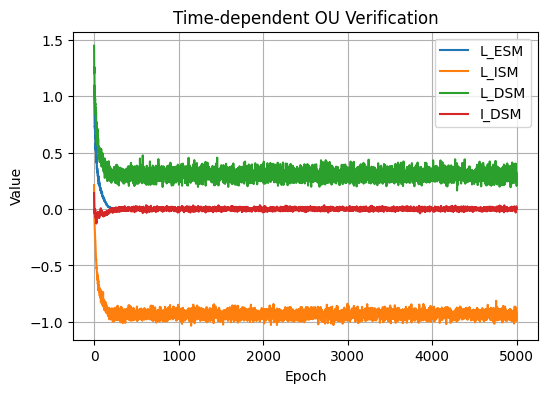

In [4]:
plt.figure(figsize=(6,4))

plt.plot(L_ESM_history, label='L_ESM')
plt.plot(L_ISM_history, label='L_ISM')
plt.plot(L_DSM_history, label='L_DSM')
plt.plot(I_DSM_history, label='I_DSM')

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Time-dependent OU Verification")

plt.legend()
plt.grid(True)

plt.show()

# Reverse

In [5]:
# ============================================================
# Reverse OU Sampling: x_T -> x_eps -> x_0
# ============================================================

model.eval()

num_samples = 5000
steps = 1000

eps_t = 0.05
dt = (T - eps_t) / steps

# start from p_T
a_T = np.exp(-beta * T)

cond_var_T = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * T))
)

mu_T = a_T * mu0
var_T = (a_T**2) * var0 + cond_var_T

x = torch.randn(num_samples, 1) * np.sqrt(var_T) + mu_T

# ============================================================
# Reverse SDE from T to eps_t
# ============================================================

with torch.no_grad():

    for i in range(steps):

        t_now = T - i * dt

        t_tensor = torch.ones_like(x) * t_now

        score = model(x, t_tensor)

        noise = torch.randn_like(x)

        x = (
            x
            + (beta * x + sigma**2 * score) * dt
            + sigma * np.sqrt(dt) * noise
        )

# x is approximately x_eps
x_eps = x

# ============================================================
# Posterior sampling: x_0 | x_eps
# ============================================================

a_eps = np.exp(-beta * eps_t)

cond_var_eps = (
    sigma**2 / (2 * beta)
    * (1 - np.exp(-2 * beta * eps_t))
)

mu_eps = a_eps * mu0

var_eps = (
    (a_eps**2) * var0
    + cond_var_eps
)

# posterior mean of x0 | x_eps
post_mean = (
    mu0
    + (a_eps * var0 / var_eps)
    * (x_eps - mu_eps)
)

# posterior variance of x0 | x_eps
post_var = (
    var0
    - (a_eps**2 * var0**2) / var_eps
)

# sample x0
x0_reverse = (
    post_mean
    + torch.sqrt(torch.tensor(post_var)) * torch.randn_like(post_mean)
)

samples_reverse = x0_reverse.cpu().numpy().flatten()

print("Reverse mean:", samples_reverse.mean())
print("Reverse std:", samples_reverse.std())

print("Target p0 mean:", mu0)
print("Target p0 std:", np.sqrt(var0))

Reverse mean: 9.998784
Reverse std: 1.4398149
Target p0 mean: 10.0
Target p0 std: 1.4142135623730951


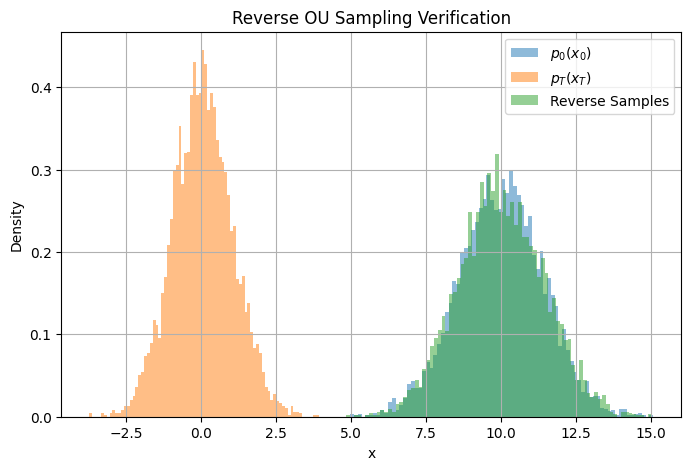

In [6]:
x0_true = np.random.normal(mu0, np.sqrt(var0), 5000)
xT_true = np.random.normal(mu_T, np.sqrt(var_T), 5000)

plt.figure(figsize=(8,5))

plt.hist(x0_true, bins=80, density=True, alpha=0.5, label=r'$p_0(x_0)$')
plt.hist(xT_true, bins=80, density=True, alpha=0.5, label=r'$p_T(x_T)$')
plt.hist(samples_reverse, bins=80, density=True, alpha=0.5, label='Reverse Samples')

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Reverse OU Sampling Verification")
plt.legend()
plt.grid(True)
plt.show()

這張圖以前證明了我的diffusion model的reverse process 可以recover training distribution。
但p_0跟p_reverse的distribution distance可能在想一下怎麼計算

# 實驗1: x_input=10, 做2000次獨立的forward-noise+reverse reconstruction
改變不同的noise level "t_list = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0]"  
p0是N(10,2)  
然後現在x_input是10，對每個noise level t 獨立 recover 2000次  
而histogram畫的是$p(\hat{x}_0|x_{input}=10,t)$ 的MonteCarlo approximation。  
也就是**一張 histogram = 同一個 input 在同一 noise level 下，重複 reconstruction 很多次後，最後可能落在哪裡。**

In [12]:
# Different noise levels
t_list = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0]

t = 0.5 | mean = 10.0219 | std = 1.1768 | MSE to input = 1.3852
t = 1.0 | mean = 9.9975 | std = 1.3761 | MSE to input = 1.8936
t = 2.0 | mean = 9.9868 | std = 1.3972 | MSE to input = 1.9523
t = 3.0 | mean = 9.8930 | std = 1.4121 | MSE to input = 2.0056
t = 4.0 | mean = 9.9901 | std = 1.4528 | MSE to input = 2.1107
t = 5.0 | mean = 9.9992 | std = 1.4092 | MSE to input = 1.9859


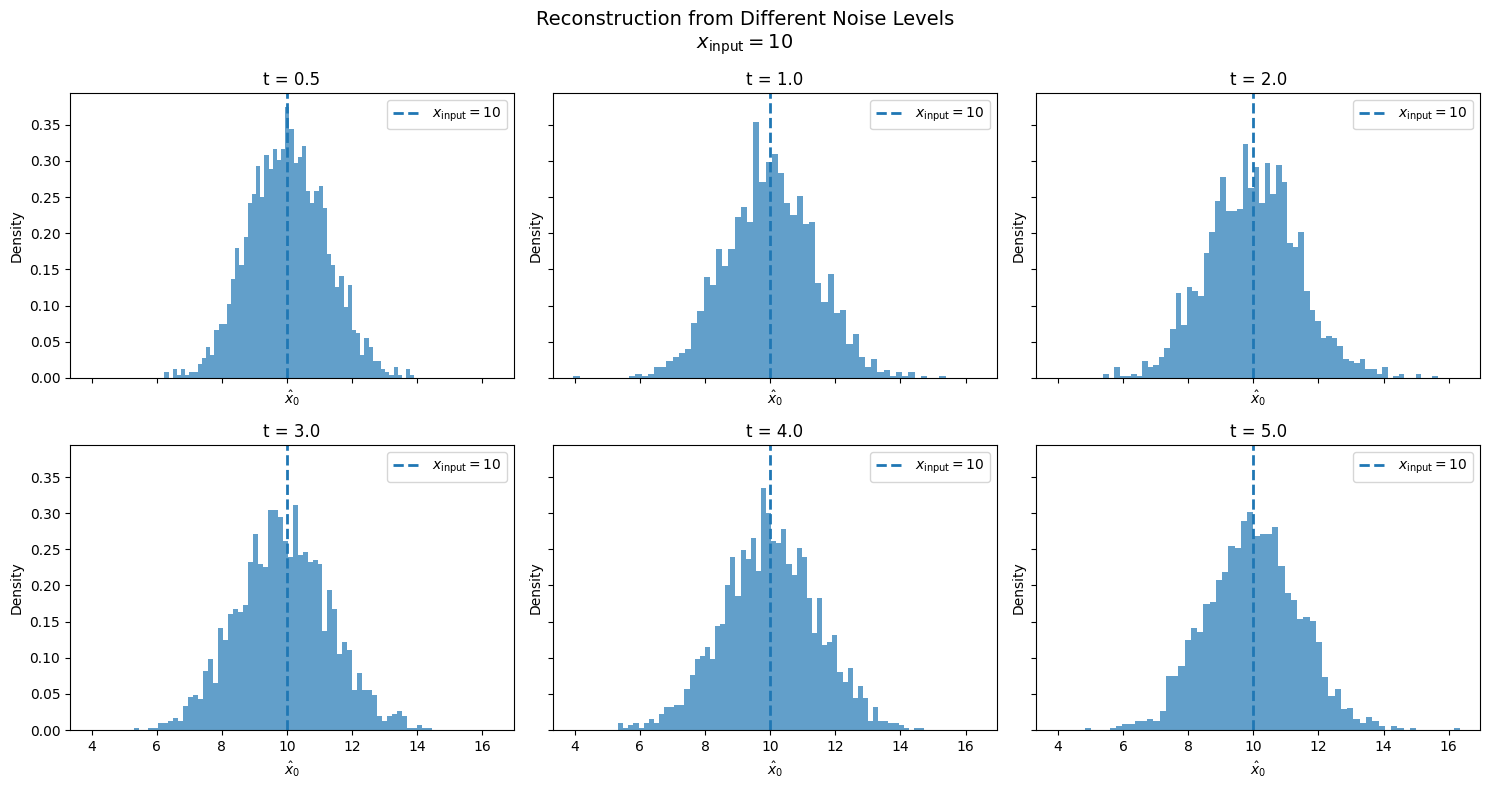

In [13]:
# 1. Reconstruction experiment
# Fixed input x0 = 10, different noise levels t
# ============================================================


device = next(model.parameters()).device

# OU parameters (same as previous experiment)
beta = 1.0
sigma = np.sqrt(2.0)

# Fixed input
x_input = 10.0

# Number of repeated reconstructions
n_samples = 2000

# Number of reverse steps
n_reverse_steps = 1000


# ------------------------------------------------------------
# 1. Forward OU: x0 -> xt
# ------------------------------------------------------------
def forward_ou(x0, t, n_samples):
    """
    Sample x_t | x_0 for OU process:
    
    x_t = exp(-beta*t) x0
          + sqrt[sigma^2/(2beta) * (1-exp(-2beta*t))] * eps
    """

    mean = np.exp(-beta * t) * x0

    std = np.sqrt(
        (sigma**2 / (2 * beta))
        * (1 - np.exp(-2 * beta * t))
    )

    eps = np.random.randn(n_samples)

    xt = mean + std * eps

    return xt


# ------------------------------------------------------------
# 2. Reverse OU: xt -> x0_hat
# ------------------------------------------------------------
@torch.no_grad()
def reverse_from_t(xt, t_start, model, n_steps=1000):

    x = torch.tensor(
        xt,
        dtype=torch.float32,
        device=device
    ).reshape(-1, 1)

    dt = t_start / n_steps

    model.eval()

    for i in range(n_steps):

        # current time: t_start -> 0
        t_now = t_start - i * dt

        t_batch = torch.full(
            (x.shape[0], 1),
            t_now,
            dtype=torch.float32,
            device=device
        )

        # learned score s_theta(x,t)
        score = model(x, t_batch)

        # Reverse-time OU SDE
        #
        # dX = [beta*x + sigma^2*score] dt
        #      + sigma*dW
        #
        drift = beta * x + (sigma**2) * score

        if i < n_steps - 1:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (
            x
            + drift * dt
            + sigma * np.sqrt(dt) * noise
        )

    return x.cpu().numpy().flatten()


# ------------------------------------------------------------
# 3. Reconstruction for different t
# ------------------------------------------------------------
results = {}

for t in t_list:

    # x_input -> x_t
    xt = forward_ou(
        x_input,
        t,
        n_samples
    )

    # x_t -> x0_hat
    x0_hat = reverse_from_t(
        xt,
        t,
        model,
        n_steps=n_reverse_steps
    )

    results[t] = x0_hat

    print(
        f"t = {t:.1f} | "
        f"mean = {x0_hat.mean():.4f} | "
        f"std = {x0_hat.std():.4f} | "
        f"MSE to input = {np.mean((x0_hat-x_input)**2):.4f}"
    )


# ------------------------------------------------------------
# 4. Plot reconstruction distributions
# ------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, t in zip(axes, t_list):

    x0_hat = results[t]

    ax.hist(
        x0_hat,
        bins=60,
        density=True,
        alpha=0.7
    )

    # Original input
    ax.axvline(
        x_input,
        linestyle="--",
        linewidth=2,
        label=r"$x_{\mathrm{input}}=10$"
    )

    ax.set_title(f"t = {t}")

    ax.set_xlabel(r"$\hat{x}_0$")
    ax.set_ylabel("Density")

    ax.legend()

plt.suptitle(
    "Reconstruction from Different Noise Levels\n"
    r"$x_{\mathrm{input}}=10$",
    fontsize=14
)

plt.tight_layout()
plt.show()